# Compare framing explanations, evidence, actors, and events

This standalone notebook aligns Gemma and Qwen segments by identifier, checks comparability, and compares five content fields, including framing_actors and framed_actors as separate variables. It complements the frame-label/type notebook.

**Start here:** edit Section 1, run Sections 2–3, and inspect the detected columns and raw examples. Configure list separators and dictionary keys before interpreting results. Then Run All. Inputs are read without modification; outputs are written to a separate directory.

The source CSVs could not be inspected during notebook creation. Column aliases are detected, but field formats must be verified against the previews. The workflow was tested using synthetic Chinese/English text, JSON lists, structured events, repeated evidence, missing values, errors and unmatched rows. No results from the original CSVs are precomputed.

Core dependency: `pandas`, `numpy`. Optional: `sentence-transformers` for semantic similarity, `matplotlib` for charts. Installation, if needed, in a separate cell:

```python
%pip install pandas numpy matplotlib
# Optional, before enabling semantic similarity:
# %pip install sentence-transformers
```

**Interpretation:** these are model comparisons, not accuracy estimates. Shared missing values are tracked, never assigned similarity 1. High embedding similarity does not demonstrate compatible reasoning or exclude contradictions. The review export supports manual checking.

## 1. Settings

Default input paths match your original notebook. Explanations are prose. The other fields support plain text, delimiter-separated values, JSON strings/lists/dictionaries, or (for events) structured JSON records. `auto` parses valid JSON, otherwise splits on the configured literal separator; it does not infer names or extract events from prose.

Set a separator to `None` to keep a whole field as one item. Do not split names on commas unless commas really separate items. Alias mapping for actors is explicit; no automatic entity resolution is performed. Blank values, JSON null, empty lists and empty dictionaries are treated as missing; other strings such as `NONE` are retained unless explicitly configured below.

`framing_actors` and `framed_actors` are distinct comparison fields with independent column overrides, list formats, separators and dictionary keys. If one is absent, only that field is marked unavailable; the other remains comparable. Verify their substantive meanings against your annotation instructions. Both enter the summary, grouped analyses, charts and manual-review export separately.


In [1]:
from pathlib import Path

CSV_A = Path('data/frames_debate_complete_gemma3_27b.csv')
CSV_B = Path('dara/frames_debate_complete_qwen3.5_35b.csv')
OUTPUT_DIR = Path('content_comparison_output')  # Relative to the kernel working directory.
NAME_A, NAME_B = 'Gemma 3 27B', 'Qwen 3.5 35B'
JOIN_KEYS = None  # Auto: _row_id, otherwise doc_id + segment_index.

# Overrides may differ by side; None means try the listed aliases.
FIELD_COLUMNS = {
    'explanation': {'a': None, 'b': None},
    'evidence': {'a': None, 'b': None},
    'framing_actors': {'a': None, 'b': None},
    'framed_actors': {'a': None, 'b': None},
    'events': {'a': None, 'b': None},
}
FIELD_ALIASES = {
    'explanation': ['frame_explanation'],
    'evidence': ['frame_evidence'],
    'framing_actors': ['framing_actors'],
    'framed_actors': ['framed_actors'],
    'events': ['framed_events'],
}
SOURCE_TEXT_COLUMNS = {'a': 'segment_text', 'b': 'segment_text'}
LABEL_COLUMNS = {'a': 'frame_label', 'b': 'frame_label'}
ERROR_COLUMNS = {'a': 'frame_processing_error', 'b': 'frame_processing_error'}

LIST_FORMAT = {'evidence': 'auto', 'framing_actors': 'auto', 'framed_actors': 'auto', 'events': 'auto'}  # auto/json/text
ITEM_SEPARATOR = {'evidence': '|', 'framing_actors': '|', 'framed_actors': '|', 'events': '|'}
ITEM_TEXT_KEYS = {
    'evidence': ['quote', 'text', 'evidence'],
    'framing_actors': ['name', 'actor', 'text'],
    'framed_actors': ['name', 'actor', 'text'],
    'events': ['description', 'event', 'text'],
}
# If an event dictionary contains one of these keys, its available components
# are compared as one complete normalized structured record (no fuzzy matching).
EVENT_COMPONENT_KEYS = ['actor', 'action', 'target', 'time', 'location']
MISSING_STRINGS = set()  # Example: {'none', 'n/a'}; case-insensitive exact matches.
ACTOR_FIELDS = {'framing_actors', 'framed_actors'}
# Apply the same explicit name/alias normalization to both actor variables.
ACTOR_ALIASES = {}  # Example: {'united states': '美国', 'usa': '美国'}.

GROUP_BY = ['topic_type', 'gender_mentioned', 'decade']  # Separate analyses, not intersections.
TOPIC_SEPARATOR = '|'
ENABLE_SEMANTIC = True  # Set True after installing sentence-transformers.
EMBEDDING_MODEL = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
EMBEDDING_REVISION = None  # Optional immutable Hugging Face revision for reproducibility.
SEMANTIC_FIELDS = ['explanation', 'events']
SEMANTIC_BATCH_SIZE = 32
ALLOW_MODEL_DOWNLOAD = True  # First enabled run may download model weights; False = cached files only.
MAKE_PLOTS = True
REVIEW_SAMPLE_SIZE = 100
RANDOM_SEED = 42
PREVIEW_ROWS = 5


## 2. Load, inspect, and align

Matching uses identifiers, never row position. Blank/duplicate identifiers stop the run. Missing content columns are reported and skipped; explicit misspelled overrides stop the run. If several aliases exist, the first alias is used and a warning asks you to choose explicitly.

Pairs with different source text, a true processing-error flag, or an unrecognized nonblank error flag are excluded from scores. If source-text/error columns are absent, that check cannot be performed and is recorded in provenance. `NOT_FRAMED` does not automatically exclude populated fields: explanations may still be meaningful. Label combinations are exported for context.

In [2]:
import json
import re
import unicodedata
import platform
import importlib.metadata
from datetime import datetime, timezone
import numpy as np
import pandas as pd

CSV_A, CSV_B, OUTPUT_DIR = map(Path, (CSV_A, CSV_B, OUTPUT_DIR))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out = OUTPUT_DIR

def write_csv(df, filename):
    df.to_csv(out / filename, index=False, encoding='utf-8-sig')

def normalize(value):
    return ' '.join(unicodedata.normalize('NFKC', str(value)).split()).casefold()

missing_strings = {normalize(x) for x in MISSING_STRINGS}
actor_aliases = {normalize(k): normalize(v) for k, v in ACTOR_ALIASES.items()}

def is_missing(value):
    return value is None or normalize(value) == '' or normalize(value) in missing_strings

a, b = [pd.read_csv(p, dtype=str, keep_default_na=False, encoding='utf-8-sig')
        for p in (CSV_A, CSV_B)]
keys = JOIN_KEYS or (['_row_id'] if '_row_id' in a and '_row_id' in b else ['doc_id', 'segment_index'])
for side, df in [('a', a), ('b', b)]:
    if not set(keys).issubset(df):
        raise ValueError(f'Model {side}: missing join keys {set(keys) - set(df.columns)}')
    if df[keys].apply(lambda s: s.str.strip().eq('')).any().any():
        raise ValueError(f'Model {side}: blank join keys')
    if df.duplicated(keys).any():
        raise ValueError(f'Model {side}: duplicate join keys; inspect {df.loc[df.duplicated(keys, keep=False), keys].head().to_dict("records")}')

resolved = {}; column_notes = []
for field, aliases in FIELD_ALIASES.items():
    resolved[field] = {}
    for side, df in [('a', a), ('b', b)]:
        explicit = FIELD_COLUMNS[field][side]
        if explicit is not None and explicit not in df:
            raise ValueError(f'Model {side}: configured {field} column {explicit!r} is absent')
        candidates = [c for c in aliases if c in df]
        selected = explicit or (candidates[0] if candidates else None)
        resolved[field][side] = selected
        if len(candidates) > 1 and explicit is None:
            column_notes.append(f'{field}/{side}: several columns found {candidates}; selected {selected}. Set an override if necessary.')
        if selected is None:
            column_notes.append(f'{field}/{side}: column absent; this field cannot be compared.')

def suffixed(df, side):
    return df.rename(columns={c: f'{c}_{side}' for c in df if c not in keys})

joined = suffixed(a, 'a').merge(suffixed(b, 'b'), on=keys, how='outer',
                              validate='one_to_one', indicator=True)
write_csv(joined.loc[joined['_merge'].ne('both')], 'unmatched_segments.csv')
pairs = joined.loc[joined['_merge'].eq('both')].drop(columns='_merge').fillna('').reset_index(drop=True)

def raw(row, column, side):
    if column is None:
        return ''
    return row.get(column if column in keys else f'{column}_{side}', '')

def source_available(side):
    return SOURCE_TEXT_COLUMNS[side] is not None and SOURCE_TEXT_COLUMNS[side] in (a if side == 'a' else b)

for side, df in [('a', a), ('b', b)]:
    for kind, config in [('source text', SOURCE_TEXT_COLUMNS), ('processing error', ERROR_COLUMNS)]:
        if config[side] is None or config[side] not in df:
            column_notes.append(f'Model {side}: {kind} column absent/disabled; check unavailable.')

def pair_issues(row):
    reasons=[]
    if all(source_available(s) for s in ('a', 'b')) and raw(row, SOURCE_TEXT_COLUMNS['a'], 'a') != raw(row, SOURCE_TEXT_COLUMNS['b'], 'b'):
        reasons.append('segment_text_mismatch')
    for side in ('a', 'b'):
        flag=normalize(raw(row, ERROR_COLUMNS[side], side))
        if flag in {'true', '1', 'yes'}:
            reasons.append(f'processing_error_{side}')
        elif flag not in {'', 'false', '0', 'no'}:
            reasons.append(f'unknown_processing_error_flag_{side}')
    return ';'.join(reasons)

pairs['pair_quality_reasons'] = pd.Series([pair_issues(r) for _, r in pairs.iterrows()], index=pairs.index, dtype=str)
pairs['pair_eligible'] = pairs.pair_quality_reasons.eq('')
for side in ('a', 'b'):
    pairs[f'comparison_label_{side}'] = pd.Series([str(raw(r, LABEL_COLUMNS[side], side)).strip().upper() for _, r in pairs.iterrows()], index=pairs.index, dtype=str)

print(f'{NAME_A}: {len(a):,} rows; {NAME_B}: {len(b):,} rows; matched: {len(pairs):,}; pair-eligible: {int(pairs.pair_eligible.sum()):,}')
for note in column_notes: print('NOTE:', note)
display(pd.DataFrame([{'field': f, 'model_a_column': v['a'], 'model_b_column': v['b']} for f,v in resolved.items()]))
for field in resolved:
    preview = pairs[keys].head(PREVIEW_ROWS).copy()
    for side in ('a','b'):
        preview[f'{field}_{side}'] = [raw(r, resolved[field][side], side) for _,r in pairs.head(PREVIEW_ROWS).iterrows()]
    print(field); display(preview)


Gemma 3 27B: 4,634 rows; Qwen 3.5 35B: 4,634 rows; matched: 4,634; pair-eligible: 4,621


,field,model_a_column,model_b_column
0,explanation,frame_explanation,frame_explanation
1,evidence,frame_evidence,frame_evidence
2,framing_actors,framing_actors,framing_actors
3,framed_actors,framed_actors,framed_actors
4,events,framed_events,framed_events


explanation


,_row_id,explanation_a,explanation_b
0,SPP191603191101::seg1,This text presents multiple frames. The 'moral...,The text explicitly frames the moral character...
1,SPP191805280301::seg1,This passage exhibits multiple frames. **Victi...,The text presents a **patriotism (positive)** ...
2,SPP191810141001::seg1,This passage exhibits both modernization (posi...,The text presents the post-war educational ref...
3,SPP191911300601::seg1,This text exhibits multiple frames. The patrio...,The text presents students as actively engagin...
4,SPP192010210601::seg1,The text presents a multifaceted situation cen...,The text presents a patriotism (positive) fram...


evidence


...

,_row_id,framing_actors_a,framing_actors_b
0,SPP191603191101::seg1,吾國人|今之爲父兄者,吾國人
1,SPP191805280301::seg1,unspecified,常處長|吳總監|阮君
2,SPP191810141001::seg1,寰球中國學生會|中華職業教育社總書記蔣夢麟博士,蔣夢麟博士
3,SPP191911300601::seg1,學生六百代表|中國各處人士,學生六百代表三十學校|羣衆
4,SPP192010210601::seg1,大會所|張仲仁|蘇省旅京同鄉,蘇省旅京同鄉|代表|學生


framed_actors


,_row_id,framed_actors_a,framed_actors_b
0,SPP191603191101::seg1,吾國人|靑年子弟,吾國人|子弟
1,SPP191805280301::seg1,留學生,同人等|學生|日本|日人|政府|當局
2,SPP191810141001::seg1,德國|聨軍|英國|法國,世界戰後之教育問題|德國
3,SPP191911300601::seg1,日人,學生|中國各處人士
4,SPP192010210601::seg1,督軍|各省|軍人,督軍制|督軍


events


,_row_id,events_a,events_b
0,SPP191603191101::seg1,道德不修|工商之不振|人羣進化,道德不修爭尙欺詐|天演淘汰
1,SPP191805280301::seg1,警察干涉|中日共同出兵軍事協定|中日陸軍共同防敵軍事協定,中日共同出兵軍事協定|亡國警耗|偵探朝夕跟隨陰爲監視|日警凌辱|陸海軍事共同協定|交涉
2,SPP191810141001::seg1,世界戰後之教育|歐戰|英德戰,unspecified
3,SPP191911300601::seg1,福州事件|日本出兵示威,北京各街游行|抵制日貨|福州事件
4,SPP192010210601::seg1,廢督運動|改制問題|軍事善後,廢督運動|組織一蘇省旅京學生聯合會


## 3. Parsing and comparison helpers

**Lexical overlap:** character bigram Jaccard after Unicode/whitespace/case normalization. This works without Chinese word segmentation, but only measures wording overlap. Punctuation is preserved. Exact text equality is also reported.

**Framing actors, framed actors, and events:** exact unordered-set agreement and Jaccard are calculated after parsing. Both actor variables use your explicit alias map, but are parsed and scored independently; their sets are never merged. Structured events compare complete normalized JSON records; participant-role differences remain differences. Unstructured event descriptions compare as text items and may disagree lexically even when they describe the same event. Actor roles in dictionaries are not compared when a name key is used; raw records remain available for review. Unknown dictionary formats are flagged rather than guessed.

**Evidence:** each quote must match the source literally after removal of whitespace. Punctuation, spelling and character variants remain significant. Straight/curly outer quotation marks are removed. Evidence overlap compares covered source-character positions, not vocabulary. All quotes on both sides must be located uniquely for the score to be eligible. Repeated quotes are flagged as ambiguous; paraphrases/unlocated quotes are flagged for review. Spans are half-open `[start, end)` offsets in the original Python string. JSON span inputs are not interpreted as offsets; use quote/text keys.

In [3]:
def parse_items(value, field):
    if is_missing(value): return [], ''
    fmt=LIST_FORMAT[field]
    if fmt not in {'auto','json','text'}: raise ValueError(f'Invalid LIST_FORMAT for {field}: {fmt}')
    value=str(value).strip()
    parsed=value
    if fmt == 'json' or (fmt == 'auto' and (value[:1] in ['[','{','"'] or value == 'null')):
        try: parsed=json.loads(value)
        except json.JSONDecodeError:
            return [], 'invalid_json'
    if parsed is None: return [], ''
    if isinstance(parsed, (list,dict)) and not parsed: return [], ''
    if isinstance(parsed,str):
        sep=ITEM_SEPARATOR[field]
        if sep == '': raise ValueError(f'Empty separator for {field}; use None to disable splitting')
        values=parsed.split(sep) if sep else [parsed]
    elif isinstance(parsed,list): values=parsed
    elif isinstance(parsed,dict): values=[parsed]
    else: return [], 'unsupported_value_type'
    items=[]
    for item in values:
        if item is None: continue
        if isinstance(item,dict):
            if field=='events' and any(k in item for k in EVENT_COMPONENT_KEYS):
                components={k:item[k] for k in EVENT_COMPONENT_KEYS if k in item}
                items.append(json.dumps(components, ensure_ascii=False, sort_keys=True));continue
            key=next((k for k in ITEM_TEXT_KEYS[field] if k in item and isinstance(item[k],str)),None)
            if key is None: return [], 'unsupported_item_dictionary'
            item=item[key]
        if not isinstance(item,str): return [], 'unsupported_item_type'
        if not is_missing(item): items.append(item.strip())
    return list(dict.fromkeys(items)), ''

def canonical_json(value):
    if isinstance(value,str): return normalize(value)
    if isinstance(value,dict): return {k:canonical_json(v) for k,v in sorted(value.items())}
    if isinstance(value,list): return [canonical_json(v) for v in value]
    return value

def item_set(items, field):
    values=set()
    for item in items:
        if field=='events' and item.startswith('{'):
            try: v=json.dumps(canonical_json(json.loads(item)),ensure_ascii=False,sort_keys=True)
            except json.JSONDecodeError: v=normalize(item)
        else: v=normalize(item)
        if field in ACTOR_FIELDS: v=actor_aliases.get(v,v)
        values.add(v)
    return values

def set_jaccard(x,y):
    return len(x & y)/len(x | y) if x | y else np.nan

def bigrams(text):
    text=normalize(text)
    return {text[i:i+2] for i in range(len(text)-1)} if len(text)>1 else ({text} if text else set())

def evidence_positions(source, items):
    # Map whitespace-stripped positions back to original source offsets.
    pos=[i for i,ch in enumerate(source) if not ch.isspace()]
    compact=''.join(source[i] for i in pos)
    covered=set();spans=[];located=0;ambiguous=0;unlocated=0
    for quote in items:
        quote=quote.strip()
        if len(quote)>1 and (quote[0],quote[-1]) in [('"','"'),("'","'"),('“','”'),('‘','’')]: quote=quote[1:-1]
        target=''.join(ch for ch in quote if not ch.isspace())
        starts=[];start=0
        if target:
            while True:
                start=compact.find(target,start)
                if start<0:break
                starts.append(start);start+=1
        if not starts: unlocated+=1;continue
        located+=1
        if len(starts)>1: ambiguous+=1;continue
        start=starts[0];indices=pos[start:start+len(target)]
        covered.update(indices);spans.append([indices[0],indices[-1]+1])
    return covered, spans, located, ambiguous, unlocated


## 4. Compare populated fields and evidence passages

Main lexical/set metrics require both fields to be populated, successfully parsed, and pair-eligible. Missing fields are not assumed to be deliberate absences: they are counted separately. Exclusion is per field, so a bad actor list does not discard a valid explanation.

The evidence-position metric has additional conditions: matching, available source text and uniquely located quotes on both sides. Missing scores mean not applicable/eligible, not zero similarity. Inspect `status` and `issues` alongside each score. Presence patterns describe all matched pairs; quality exclusions are stated separately.

In [4]:
records=[]
for i,row in pairs.iterrows():
    for field in resolved:
        x,y=[raw(row,resolved[field][side],side) for side in ('a','b')]
        if field=='explanation':
            ix,iy=([x] if not is_missing(x) else []),([y] if not is_missing(y) else [])
            ex=ey=''
        else:
            ix,ex=parse_items(x,field);iy,ey=parse_items(y,field)
        column_ok=all(resolved[field][side] is not None for side in ('a','b'))
        sx,sy=item_set(ix,field),item_set(iy,field)
        issues=[f'{side}:{error}' for side,error in [('a',ex),('b',ey)] if error]
        if not column_ok: presence='column_unavailable'
        elif ex or ey: presence='parse_error'
        elif ix and iy: presence='both_present'
        elif ix: presence='a_only'
        elif iy: presence='b_only'
        else: presence='both_missing'
        eligible=bool(row.pair_eligible) and presence=='both_present'
        # Explanation text is compared in original order; list content is order-independent.
        tx=normalize(x) if field=='explanation' else ' | '.join(sorted(sx))
        ty=normalize(y) if field=='explanation' else ' | '.join(sorted(sy))
        r={'pair_index':i, **{k:row[k] for k in keys}, 'field':field,
           'label_a':row.comparison_label_a,'label_b':row.comparison_label_b,
           'pair_eligible':bool(row.pair_eligible),'pair_quality_reasons':row.pair_quality_reasons,
           'raw_a':x,'raw_b':y,'normalized_a':tx,'normalized_b':ty,
           'presence':presence,'n_items_a':len(sx),'n_items_b':len(sy),
           'comparison_eligible':eligible,'exact_agree':float(tx==ty) if eligible else np.nan,
           'char_bigram_jaccard':set_jaccard(bigrams(tx),bigrams(ty)) if eligible else np.nan,
           'item_set_jaccard':set_jaccard(sx,sy) if eligible and field!='explanation' else np.nan,
           'items_only_a':json.dumps(sorted(sx-sy),ensure_ascii=False) if eligible else '',
           'items_only_b':json.dumps(sorted(sy-sx),ensure_ascii=False) if eligible else '',
           'semantic_cosine':np.nan, 'evidence_position_jaccard':np.nan,
           'evidence_position_eligible':False,'issues':';'.join(issues)}
        if field=='evidence':
            sources=[str(raw(row,SOURCE_TEXT_COLUMNS[s],s)) for s in ('a','b')]
            cov=[];counts=[]
            for side,source,items in zip(('a','b'),sources,(ix,iy)):
                covered,spans,located,ambiguous,unlocated=evidence_positions(source,items)
                cov.append(covered);counts.append((located,ambiguous,unlocated))
                r.update({f'evidence_spans_{side}':json.dumps(spans),
                          f'evidence_quotes_total_{side}':len(items),
                          f'evidence_quotes_located_{side}':located,
                          f'evidence_quotes_ambiguous_{side}':ambiguous,
                          f'evidence_quotes_unlocated_{side}':unlocated})
                if ambiguous:issues.append(f'ambiguous_quote_{side}')
                if unlocated:issues.append(f'unlocated_quote_{side}')
            if not all(source_available(s) for s in ('a','b')): issues.append('source_column_unavailable')
            elif not all(sources): issues.append('source_text_missing')
            evidence_ok=(eligible and all(source_available(s) for s in ('a','b'))
                         and bool(sources[0]) and sources[0]==sources[1]
                         and all(amb==0 and unloc==0 for _,amb,unloc in counts) and all(cov))
            r['evidence_position_eligible']=bool(evidence_ok)
            if evidence_ok:r['evidence_position_jaccard']=set_jaccard(*cov)
        r['issues']=';'.join(issues)
        r['status']=('pair_excluded' if not row.pair_eligible else presence)
        records.append(r)
columns=['pair_index',*keys,'field','label_a','label_b','pair_eligible','pair_quality_reasons',
         'raw_a','raw_b','normalized_a','normalized_b','presence','n_items_a','n_items_b',
         'comparison_eligible','exact_agree','char_bigram_jaccard','item_set_jaccard',
         'items_only_a','items_only_b','semantic_cosine','evidence_position_jaccard',
         'evidence_position_eligible','issues','status']
comparisons=pd.DataFrame(records) if records else pd.DataFrame(columns=columns)
display(comparisons[keys+['field','presence','comparison_eligible','item_set_jaccard','char_bigram_jaccard','evidence_position_jaccard','issues']].head(20))


,_row_id,field,presence,comparison_eligible,item_set_jaccard,char_bigram_jaccard,evidence_position_jaccard,issues
0,SPP191603191101::seg1,explanation,both_present,True,NaN,0.521595,NaN,
1,SPP191603191101::seg1,evidence,both_present,True,0.333333,0.240964,0.250000,
2,SPP191603191101::seg1,framing_actors,both_present,True,0.500000,0.181818,NaN,
3,SPP191603191101::seg1,framed_actors,both_present,True,0.333333,0.600000,NaN,
4,SPP191603191101::seg1,events,both_present,True,0.000000,0.250000,NaN,
5,SPP191805280301::seg1,explanation,both_present,True,NaN,0.591045,NaN,
6,SPP191805280301::seg1,evidence,both_present,True,0.000000,0.390533,0.371429,
7,SPP191805280301::seg1,framing_actors,both_present,True,0.000000,0.000000,NaN,
8,SPP191805280301::seg1,framed_actors,both_present,True,0.000000,0.052632,NaN,
9,SPP191805280301::seg1,events,both_present,True,0.125000,0.230769,NaN,


## 5. Optional semantic similarity

Set `ENABLE_SEMANTIC = True` in Section 1 to compare explanations and event descriptions using a multilingual Sentence Transformer. It runs locally after model weights are downloaded; CSV text is not sent to an inference API. Dependencies/model files must be available. Failure is recorded explicitly; lexical outputs remain available.

The model supports multilingual text, including Chinese and English. Cosine similarity measures semantic proximity; it is **not an agreement percentage**. There is no default semantic-agreement threshold. Establish any threshold against manually reviewed pairs before treating it as a classification.

Long fields are split into token chunks within the model limit, embedded, pooled with token-count weights and normalized. This avoids silently truncating long explanations. Structured event inputs are embedded as their normalized serialized text; those scores are exploratory, not event-matching scores. Review scores alongside the originals.

References: [multilingual models](https://sbert.net/docs/sentence_transformer/pretrained_models.html), [semantic textual similarity](https://sbert.net/docs/sentence_transformer/usage/semantic_textual_similarity.html), [model card](https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2).

In [5]:
semantic_status={'enabled':ENABLE_SEMANTIC,'status':'disabled','model':EMBEDDING_MODEL,
                 'revision':EMBEDDING_REVISION,'pooling':'token-count-weighted mean of token chunks',
                 'n_scored':0}
if ENABLE_SEMANTIC:
    try:
        from sentence_transformers import SentenceTransformer
        model=SentenceTransformer(EMBEDDING_MODEL, revision=EMBEDDING_REVISION,
                                  local_files_only=not ALLOW_MODEL_DOWNLOAD)
        tokenizer=model.tokenizer
        max_tokens=int(model.max_seq_length)-tokenizer.num_special_tokens_to_add(pair=False)
        if max_tokens<1:raise ValueError('Model token limit is too small')
        mask=comparisons.comparison_eligible.eq(True) & comparisons.field.isin(SEMANTIC_FIELDS)
        texts=list(dict.fromkeys(comparisons.loc[mask,['normalized_a','normalized_b']].to_numpy().ravel()))
        chunks=[];owners=[];weights=[];chunk_counts={}
        for text in texts:
            ids=tokenizer.encode(text,add_special_tokens=False)
            parts=[ids[j:j+max_tokens] for j in range(0,len(ids),max_tokens)]
            chunk_counts[text]=len(parts)
            for part in parts:
                chunks.append(tokenizer.decode(part,skip_special_tokens=True));owners.append(text);weights.append(len(part))
        vectors={}
        if chunks:
            embeddings=model.encode(chunks,batch_size=SEMANTIC_BATCH_SIZE,normalize_embeddings=True,
                                    convert_to_numpy=True,show_progress_bar=True)
            sums={};totals={}
            for owner,weight,embedding in zip(owners,weights,embeddings):
                sums[owner]=sums.get(owner,np.zeros_like(embedding))+weight*embedding
                totals[owner]=totals.get(owner,0)+weight
            for text,v in sums.items():
                length=np.linalg.norm(v)
                if length>0:vectors[text]=v/length
            for i,row in comparisons.loc[mask].iterrows():
                if row.normalized_a in vectors and row.normalized_b in vectors:
                    comparisons.at[i,'semantic_cosine']=float(np.clip(np.dot(vectors[row.normalized_a],vectors[row.normalized_b]),-1,1))
                    comparisons.at[i,'semantic_chunks_a']=chunk_counts[row.normalized_a]
                    comparisons.at[i,'semantic_chunks_b']=chunk_counts[row.normalized_b]
        semantic_status.update(status='completed',max_chunk_tokens=max_tokens,
                               n_scored=int(comparisons.semantic_cosine.notna().sum()),
                               n_texts=len(texts),n_chunks=len(chunks))
    except Exception as error:
        # Do not leave partially computed semantic results after a failure.
        comparisons['semantic_cosine']=np.nan
        semantic_status.update(status='failed',error=f'{type(error).__name__}: {error}')
        print('Semantic comparison failed. Check dependencies/model availability, then rerun this cell. Core outputs remain usable.')
print(semantic_status)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (207 > 128). Running this sequence through the model will result in indexing errors


Batches:   0%|          | 0/866 [00:00<?, ?it/s]

{'enabled': True, 'status': 'completed', 'model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'revision': None, 'pooling': 'token-count-weighted mean of token chunks', 'n_scored': 9242, 'max_chunk_tokens': 126, 'n_texts': 17624, 'n_chunks': 27699}


## 6. Summary tables and interpretation

Every score has its own denominator. Exact agreement is a percentage; Jaccard and cosine remain raw similarity scores. For actors/events, exact agreement is equality of complete item sets. For evidence, item equality compares normalized quotations, while position Jaccard measures shared passages. Evidence location rates count quotes on pair-eligible, successfully parsed rows, including rows populated on only one side.

A short quotation wholly contained in a longer quotation has partial position overlap. Both-empty fields never enter score denominators. Missing columns and parse errors are explicitly counted. Presence counts include pair-excluded rows, so consult quality counts as well.

Read the `framing_actors` and `framed_actors` rows independently. Each reports its own eligible denominator, exact set agreement, item-set Jaccard, lexical overlap, missing values and parsing errors.


In [6]:
SCORES=['exact_agree','char_bigram_jaccard','item_set_jaccard','evidence_position_jaccard','semantic_cosine']
def summarize(frame):
    rows=[]
    for field in FIELD_ALIASES:
        sub=frame.loc[frame.field.eq(field)]
        r={'field':field,'n_matched':len(sub),'n_pair_excluded':int(sub.pair_eligible.eq(False).sum()),
           'n_both_present':int(sub.presence.eq('both_present').sum()),
           'n_both_missing':int(sub.presence.eq('both_missing').sum()),
           'n_a_only':int(sub.presence.eq('a_only').sum()),'n_b_only':int(sub.presence.eq('b_only').sum()),
           'n_parse_error':int(sub.presence.eq('parse_error').sum()),
           'n_column_unavailable':int(sub.presence.eq('column_unavailable').sum()),
           'n_comparison_eligible':int(sub.comparison_eligible.eq(True).sum())}
        for score in SCORES:
            v=pd.to_numeric(sub[score],errors='coerce').dropna()
            label='exact_agreement_pct' if score=='exact_agree' else f'mean_{score}'
            r[label]=float(v.mean())*(100 if score=='exact_agree' else 1) if len(v) else np.nan
            r[f'n_{score}']=len(v)
        rows.append(r)
    return pd.DataFrame(rows)
summary=summarize(comparisons)
write_csv(summary,'content_summary.csv')
display(summary.round(4))

location_rows=[]
ev=comparisons.loc[comparisons.field.eq('evidence') & comparisons.pair_eligible.eq(True) & comparisons.presence.ne('parse_error')]
for side in ('a','b'):
    total=int(pd.to_numeric(ev.get(f'evidence_quotes_total_{side}',pd.Series(dtype=float)),errors='coerce').sum())
    located=int(pd.to_numeric(ev.get(f'evidence_quotes_located_{side}',pd.Series(dtype=float)),errors='coerce').sum())
    ambiguous=int(pd.to_numeric(ev.get(f'evidence_quotes_ambiguous_{side}',pd.Series(dtype=float)),errors='coerce').sum())
    location_rows.append({'model_side':side,'quotes_total':total,'quotes_located':located,
                          'quotes_ambiguous':ambiguous,'quotes_uniquely_located':located-ambiguous,
                          'located_pct':100*located/total if total and source_available(side) else np.nan,
                          'source_column_available':source_available(side)})
evidence_locations=pd.DataFrame(location_rows)
write_csv(evidence_locations,'evidence_location_summary.csv');display(evidence_locations)


,field,n_matched,n_pair_excluded,n_both_present,n_both_missing,n_a_only,n_b_only,n_parse_error,n_column_unavailable,n_comparison_eligible,exact_agreement_pct,n_exact_agree,mean_char_bigram_jaccard,n_char_bigram_jaccard,mean_item_set_jaccard,n_item_set_jaccard,mean_evidence_position_jaccard,n_evidence_position_jaccard,mean_semantic_cosine,n_semantic_cosine
0,explanation,4634,13,4621,0,7,6,0,0,4621,0.0000,4621,0.5445,4621,NaN,0,NaN,0,0.7630,4621
1,evidence,4634,13,4174,56,356,48,0,0,4174,0.9104,4174,0.2283,4174,0.0624,4174,0.2172,3991,NaN,0
2,framing_actors,4634,13,4634,0,0,0,0,0,4621,16.8145,4621,0.3247,4621,0.2915,4621,NaN,0,NaN,0
3,framed_actors,4634,13,4634,0,0,0,0,0,4621,6.7301,4621,0.3226,4621,0.2410,4621,NaN,0,NaN,0
4,events,4634,13,4634,0,0,0,0,0,4621,3.0296,4621,0.2235,4621,0.1160,4621,NaN,0,0.5919,4621


,model_side,quotes_total,quotes_located,quotes_ambiguous,quotes_uniquely_located,located_pct,source_column_available
0,a,13550,13501,109,13392,99.638376,True
1,b,9797,9758,79,9679,99.601919,True


## 7. Group by individual topics, gender, and decade

Groups use model A metadata. Topic lists are split on the configured separator, deduplicated per segment, and exploded: a segment may enter several groups. Gender is kept as the stored value. Decades use integer year with YYYYMMDD/ISO date fallback. Missing metadata becomes `(missing)`. Groups are separate analyses, not intersections. Check denominators, especially for sparse groups.

In [7]:
def meta_column(name):
    if name in keys:return name
    return f'{name}_a' if name in a else None

metadata=pairs[keys].copy()
for group in GROUP_BY:
    if group=='decade':
        yc=meta_column('year');dc=meta_column('date')
        year=pd.to_numeric(pairs[yc],errors='coerce') if yc else pd.Series(np.nan,index=pairs.index)
        year=year.where(year.between(1000,9999) & year.mod(1).eq(0))
        if dc:
            dates=pairs[dc].str.strip()
            fallback=pd.to_datetime(dates,format='%Y%m%d',errors='coerce').fillna(pd.to_datetime(dates,format='%Y-%m-%d',errors='coerce')).dt.year
            year=year.fillna(fallback)
        start=((year//10)*10).astype('Int64')
        metadata[group]=[f'{int(v)}-{int(v)+9}' if pd.notna(v) else '(missing)' for v in start]
    else:
        col=meta_column(group)
        if col is None:print(f'Skipping absent model A metadata: {group}');continue
        metadata[group]=pairs[col].astype(str).str.strip().replace('','(missing)')

membership=[];group_tables=[]
for group in GROUP_BY:
    if group not in metadata:continue
    m=metadata[keys+[group]].copy().rename(columns={group:'group_value'})
    if group=='topic_type':
        if not TOPIC_SEPARATOR:raise ValueError('TOPIC_SEPARATOR must be nonempty')
        m['group_value']=m.group_value.map(lambda v: sorted({x.strip() for x in v.split(TOPIC_SEPARATOR) if x.strip()}) or ['(missing)'])
        m=m.explode('group_value')
    m.insert(len(keys),'group_column',group);membership.append(m)
    attached=comparisons.merge(m,on=keys,how='inner',validate='many_to_many')
    for value,sub in attached.groupby('group_value',sort=True):
        tab=summarize(sub);tab.insert(0,'group_value',value);tab.insert(0,'group_column',group);group_tables.append(tab)
group_summary=pd.concat(group_tables,ignore_index=True) if group_tables else pd.DataFrame(columns=['group_column','group_value',*summary.columns])
write_csv(group_summary,'content_by_group.csv')
write_csv(pd.concat(membership,ignore_index=True) if membership else pd.DataFrame(columns=keys+['group_column','group_value']),'group_membership.csv')
display(group_summary.head(30).round(4))


,group_column,group_value,field,n_matched,n_pair_excluded,n_both_present,n_both_missing,n_a_only,n_b_only,n_parse_error,...,exact_agreement_pct,n_exact_agree,mean_char_bigram_jaccard,n_char_bigram_jaccard,mean_item_set_jaccard,n_item_set_jaccard,mean_evidence_position_jaccard,n_evidence_position_jaccard,mean_semantic_cosine,n_semantic_cosine
0,topic_type,debate,explanation,1190,5,1185,0,1,4,0,...,0.0000,1185,0.5429,1185,NaN,0,NaN,0,0.7617,1185
1,topic_type,debate,evidence,1190,5,988,33,150,19,0,...,1.2146,988,0.2447,988,0.0639,988,0.2351,956,NaN,0
2,topic_type,debate,framing_actors,1190,5,1190,0,0,0,0,...,21.7722,1185,0.3172,1185,0.3087,1185,NaN,0,NaN,0
3,topic_type,debate,framed_actors,1190,5,1190,0,0,0,0,...,8.8608,1185,0.3282,1185,0.2543,1185,NaN,0,NaN,0
4,topic_type,debate,events,1190,5,1190,0,0,0,0,...,5.9072,1185,0.2246,1185,0.1378,1185,NaN,0,0.5674,1185
5,topic_type,debate; biography,explanation,1078,2,1076,0,2,0,0,...,0.0000,1076,0.5427,1076,NaN,0,NaN,0,0.7591,1076
6,topic_type,debate; biography,evidence,1078,2,993,6,75,4,0,...,1.0070,993,0.2148,993,0.0609,993,0.2017,963,NaN,0
7,topic_type,debate; biography,framing_actors,1078,2,1078,0,0,0,0,...,16.9145,1076,0.2977,1076,0.2885,1076,NaN,0,NaN,0
8,topic_type,debate; biography,framed_actors,1078,2,1078,0,0,0,0,...,7.2491,1076,0.3283,1076,0.2523,1076,NaN,0,NaN,0
9,topic_type,debate; biography,events,1078,2,1078,0,0,0,0,...,1.8587,1076,0.2025,1076,0.1055,1076,NaN,0,0.5770,1076


## 8. Export comparisons, diagnostics, and a manual review sample

`content_comparisons.csv` is a long table: five rows per matched segment. `paired_raw_outputs.csv` retains both models' source text and all original columns. Review records include source text and blank annotation fields. The sample combines a random selection with lowest available similarity scores; it is a diagnostic sample, not a representative accuracy estimate. Prefer manual review to adopting an arbitrary cosine threshold.

Suggested explanation judgments: compatible / partially compatible / contradictory / unrelated / insufficient information. Actor/event equivalence and evidence support require reading the source. Outputs may overlap and should not be added together. Re-running overwrites generated files, including the review template; save completed annotations under a different filename.

Separate exports are `comparisons_framing_actors.csv` and `comparisons_framed_actors.csv`, with `lexical_differences_framing_actors.csv` and `lexical_differences_framed_actors.csv`. Review annotations also have separate columns for the two actor variables. Use a fresh output directory if a previous run contains the retired generic `comparisons_actors.csv` file.


In [8]:
write_csv(comparisons,'content_comparisons.csv')
write_csv(pairs,'paired_raw_outputs.csv')
issues=comparisons.loc[comparisons.issues.ne('') | comparisons.pair_eligible.eq(False) | comparisons.presence.isin(['parse_error','column_unavailable'])]
write_csv(issues,'content_quality_issues.csv')
for field in FIELD_ALIASES:
    sub=comparisons.loc[comparisons.field.eq(field)]
    write_csv(sub,f'comparisons_{field}.csv')
    write_csv(sub.loc[sub.comparison_eligible.eq(True) & sub.exact_agree.eq(0)],f'lexical_differences_{field}.csv')

candidates=comparisons.loc[comparisons.pair_eligible.eq(True) & comparisons.presence.ne('column_unavailable')].copy()
def review_score(row):
    for metric in ['semantic_cosine','evidence_position_jaccard','item_set_jaccard','char_bigram_jaccard']:
        if pd.notna(row[metric]):return row[metric]
    return np.nan
candidates['review_priority_score']=candidates.apply(review_score,axis=1) if len(candidates) else pd.Series(dtype=float)
n=min(REVIEW_SAMPLE_SIZE,len(candidates));n_low=n//2
low=candidates.loc[candidates.review_priority_score.notna()].nsmallest(n_low,'review_priority_score')
remaining=candidates.drop(index=low.index)
random_sample=remaining.sample(n=min(n-len(low),len(remaining)),random_state=RANDOM_SEED)
low=low.assign(sample_reason='low_similarity');random_sample=random_sample.assign(sample_reason='random')
review=pd.concat([low,random_sample])
for side in ('a','b'):
    source_col=SOURCE_TEXT_COLUMNS[side]
    review[f'source_text_{side}']=[raw(pairs.iloc[int(i)],source_col,side) for i in review.pair_index]
for column in ['human_explanation_relation','human_evidence_supported_a','human_evidence_supported_b',
               'human_framing_actors_equivalent','human_framed_actors_equivalent','human_events_equivalent','reviewer','notes']:
    review[column]=''
write_csv(review,'manual_review_template.csv')
print(f'{len(review)} field-pair records exported for manual review.')


100 field-pair records exported for manual review.


## 9. Charts and provenance

Charts show mean similarities on a 0–1 scale (cosine may be negative); numbers in brackets are score denominators. They do not classify semantic agreement. Provenance records settings, detected columns, package versions and semantic execution status.

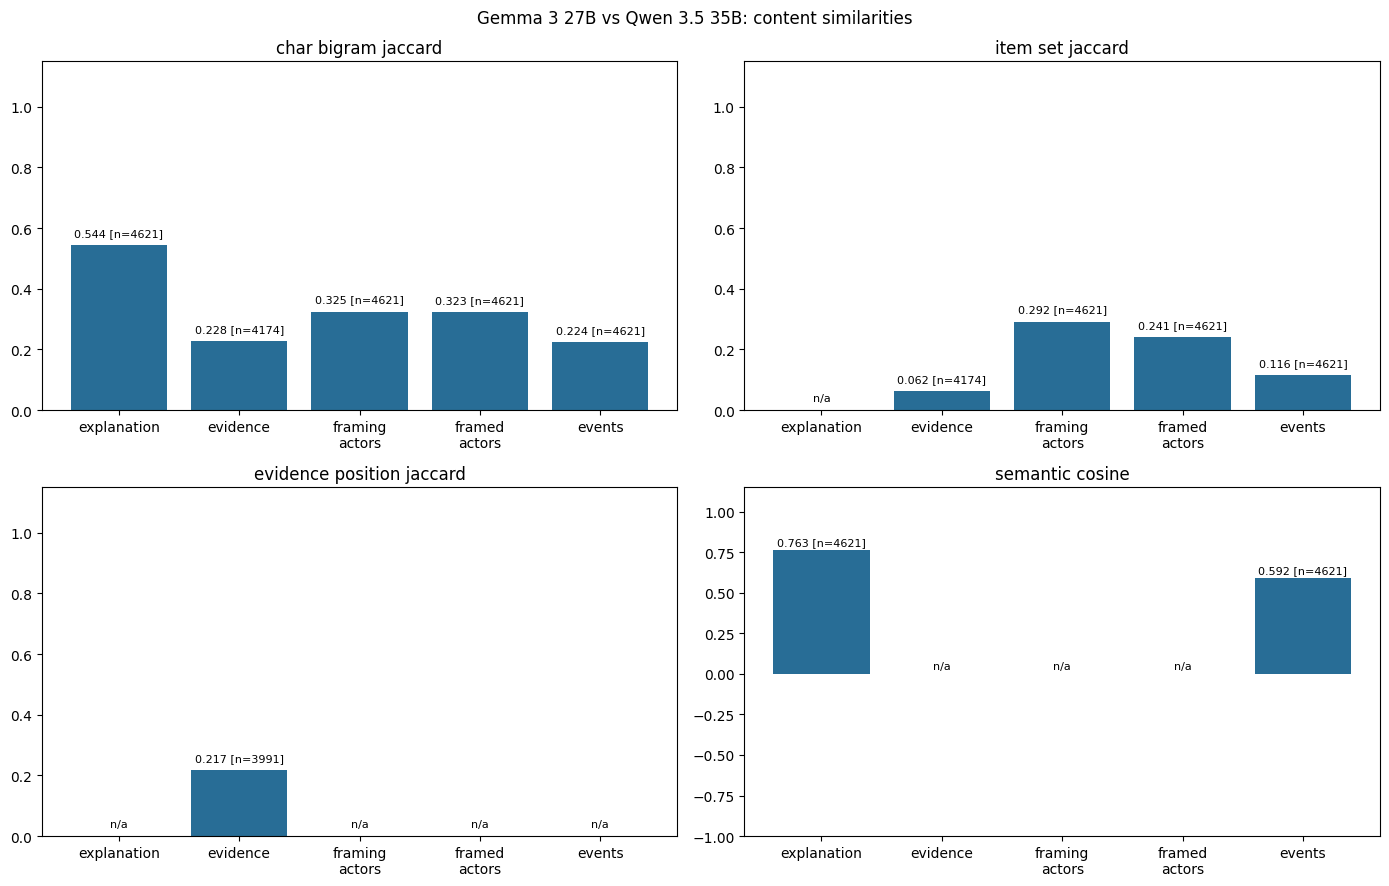

Results saved to /Users/carmand/Desktop/framing/content_comparison_output


In [9]:
if MAKE_PLOTS:
    try:
        import matplotlib.pyplot as plt
        metrics=['mean_char_bigram_jaccard','mean_item_set_jaccard','mean_evidence_position_jaccard','mean_semantic_cosine']
        fig,axes=plt.subplots(2,2,figsize=(14,9))
        for ax,metric in zip(axes.ravel(),metrics):
            values=summary[metric]
            ax.bar(summary.field,values.fillna(0),color='#286d96')
            ax.set_xticks(range(len(summary)), [v.replace('_', '\n') for v in summary.field])
            ax.set_ylim(-1 if metric.endswith('cosine') else 0,1.15)
            ax.set_title(metric.replace('mean_','').replace('_',' '))
            for j,(_,r) in enumerate(summary.iterrows()):
                value=r[metric];score=metric.removeprefix('mean_')
                ax.text(j,max(0,float(value))+0.03 if pd.notna(value) else .03,
                        f'{value:.3f} [n={int(r["n_"+score])}]' if pd.notna(value) else 'n/a',ha='center',fontsize=8)
        fig.suptitle(f'{NAME_A} vs {NAME_B}: content similarities')
        fig.tight_layout();fig.savefig(out/'content_similarities.png',dpi=180,bbox_inches='tight');plt.show();plt.close(fig)
    except ImportError:
        print('matplotlib is unavailable; CSV exports are complete.')

packages={}
for package in ['pandas','numpy','sentence-transformers','transformers','matplotlib']:
    try:packages[package]=importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:packages[package]=None
coverage={'created_utc':datetime.now(timezone.utc).isoformat(),'model_a':NAME_A,'model_b':NAME_B,
          'input_a':str(CSV_A.resolve()),'input_b':str(CSV_B.resolve()),'join_keys':keys,
          'input_rows_a':len(a),'input_rows_b':len(b),'matched_rows':len(pairs),
          'only_a':int(joined['_merge'].eq('left_only').sum()),'only_b':int(joined['_merge'].eq('right_only').sum()),
          'pair_eligible':int(pairs.pair_eligible.sum()),'resolved_field_columns':resolved,'column_notes':column_notes,
          'source_text_columns':SOURCE_TEXT_COLUMNS,'error_columns':ERROR_COLUMNS,'label_columns':LABEL_COLUMNS,
          'list_formats':LIST_FORMAT,'item_separators':ITEM_SEPARATOR,'item_text_keys':ITEM_TEXT_KEYS,
          'event_component_keys':EVENT_COMPONENT_KEYS,'missing_strings':sorted(MISSING_STRINGS),
          'actor_aliases':ACTOR_ALIASES,'actor_fields':sorted(ACTOR_FIELDS),'group_by_model_a':GROUP_BY,'topic_separator':TOPIC_SEPARATOR,
          'decade_definition':'calendar decade from model A integer year; date fallback',
          'semantic':semantic_status,'random_seed':RANDOM_SEED,'review_sample_size':REVIEW_SAMPLE_SIZE,
          'python':platform.python_version(),'packages':packages}
(out/'content_coverage.json').write_text(json.dumps(coverage,ensure_ascii=False,indent=2),encoding='utf-8')
lines=[f'{NAME_A} vs {NAME_B}',f'Matched segments: {len(pairs):,}',
       f'Pair-eligible: {int(pairs.pair_eligible.sum()):,}',
       f'Semantic comparison: {semantic_status["status"]}',
       'Scores require both fields populated. Shared missing values do not count as agreement.',
       'Lexical differences and cosine similarity are not judgments of accuracy or contradiction.',
       'Evidence position overlap requires uniquely located quotes in matching source text.',
       '',summary.to_string(index=False), '',*column_notes]
(out/'content_report.txt').write_text('\n'.join(lines)+'\n',encoding='utf-8')
print(f'Results saved to {out.resolve()}')


## 10. Read outputs in this order

1. `content_coverage.json`: confirm input paths, keys, detected columns, parsing settings, and whether semantic comparison ran.
2. `content_quality_issues.csv` and `unmatched_segments.csv`: inspect invalid formats, processing errors, source mismatches and evidence location failures.
3. `content_summary.csv`, `evidence_location_summary.csv`, `content_report.txt`, and `content_similarities.png`: overall scores with denominators.
4. `content_by_group.csv`: compare individual topics, gender values and decades; `group_membership.csv` records exactly which segments enter each group.
5. `manual_review_template.csv`: read source text and annotate a diagnostic sample before interpreting semantic scores as agreement.
6. `comparisons_explanation.csv`, `comparisons_evidence.csv`, `comparisons_framing_actors.csv`, `comparisons_framed_actors.csv`, `comparisons_events.csv` and corresponding `lexical_differences_*.csv`: detailed field-specific inspection.
7. `content_comparisons.csv` and `paired_raw_outputs.csv`: complete audit tables.

CSV exports use UTF-8 with BOM for Chinese text in Excel. Missing scores are blank in CSV files. Use a fresh output directory when changing settings so old chart files cannot be mistaken for current results.